# Retail Store Sales Forecasting DBMS

# STEP 1: Import Libraries

In [1]:
from sqlalchemy import create_engine, text
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Optional forecasting libraries
try:
    from statsmodels.tsa.statespace.sarimax import SARIMAX
    SARIMA_AVAILABLE = True
except ImportError:
    SARIMA_AVAILABLE = False
    print('statsmodels not installed — skipping SARIMA section')

try:
    from prophet import Prophet
    PROPHET_AVAILABLE = True
except ImportError:
    PROPHET_AVAILABLE = False
    print('prophet not installed — skipping Prophet section')

print('Libraries loaded ✓')

Libraries loaded ✓


# STEP 2: Database Connection

In [3]:
USER     = "postgres"
PASSWORD = "Nisha0123"   # ← update this
HOST     = "localhost"
PORT     = "5432"
DATABASE = "retail_store"
       # ← update this

engine = create_engine(
    f"postgresql+psycopg2://{USER}:{PASSWORD}@{HOST}:{PORT}/{DATABASE}"
)

# Quick connectivity test
with engine.connect() as conn:
    result = conn.execute(text("SELECT version();"))
    print('Connected:', result.fetchone()[0])

Connected: PostgreSQL 17.5 on x86_64-windows, compiled by msvc-19.44.35209, 64-bit


# STEP 3: DDL — Create Schema & Tables

In [4]:
print('Running schema.sql...')
with open('../sql/schema.sql', 'r') as f:
    schema_sql = f.read()

with engine.connect() as conn:
    # Execute statement by statement (skip blank lines)
    for statement in schema_sql.split(';'):
        stmt = statement.strip()
        if stmt:
            try:
                conn.execute(text(stmt))
            except Exception as e:
                print(f'  Note: {e}')
    conn.commit()

print('Schema created ✓')

Running schema.sql...
  Note: (psycopg2.errors.SyntaxError) unterminated dollar-quoted string at or near "$$
BEGIN
    -- Analyst: read-only
    IF NOT EXISTS (SELECT FROM pg_roles WHERE rolname = 'analyst_role') THEN
        CREATE ROLE analyst_role"
LINE 4: DO $$
           ^

[SQL: -- ============================================================
-- ROLE-BASED ACCESS CONTROL
-- ============================================================
DO $$
BEGIN
    -- Analyst: read-only
    IF NOT EXISTS (SELECT FROM pg_roles WHERE rolname = 'analyst_role') THEN
        CREATE ROLE analyst_role]
(Background on this error at: https://sqlalche.me/e/20/f405)
  Note: (psycopg2.errors.SyntaxError) syntax error at or near "IF"
LINE 1: END IF
            ^

[SQL: END IF]
(Background on this error at: https://sqlalche.me/e/20/f405)
  Note: (psycopg2.errors.SyntaxError) syntax error at or near "IF"
LINE 2:     IF NOT EXISTS (SELECT FROM pg_roles WHERE rolname = 'man...
            ^

[SQL: -- Manager: rea

# STEP 4: Load CSV Datasets

In [5]:
BASE_PATH = '../dataset/'

df_stores   = pd.read_csv(BASE_PATH + 'stores.csv')
df_sales    = pd.read_csv(BASE_PATH + 'sales.csv')
df_features = pd.read_csv(BASE_PATH + 'features.csv')

# Normalise column names
df_stores.columns   = df_stores.columns.str.strip().str.lower().str.replace(' ', '_')
df_sales.columns    = df_sales.columns.str.strip().str.lower().str.replace(' ', '_')
df_features.columns = df_features.columns.str.strip().str.lower().str.replace(' ', '_')

print('Stores:  ', df_stores.shape)
print('Sales:   ', df_sales.shape)
print('Features:', df_features.shape)

Stores:   (50, 4)
Sales:    (156000, 5)
Features: (7800, 14)


# STEP 5: Data Preprocessing

In [10]:
# ── Sales ──
df_sales['date']        = pd.to_datetime(df_sales['date'], dayfirst=True, errors='coerce')
df_sales['is_holiday']  = df_sales['is_holiday'].astype(bool)
df_sales['weekly_sales'] = pd.to_numeric(df_sales['weekly_sales'], errors='coerce')

# Remove negative sales (returns / adjustments outside scope)
df_sales = df_sales[df_sales['weekly_sales'] >= 0].copy()

# Rename for DBMS consistency
df_sales.rename(columns={
    'store_id': 'store_id',
    'department': 'dept_id',
    'date': 'sale_date',
    'weekly_sales': 'weekly_sales',
    'is_holiday': 'is_holiday'
}, inplace=True)

# ── Stores ──
df_stores.rename(columns={
    'store': 'store_id',
    'type': 'store_type',
    'size': 'store_size'
}, inplace=True)

# Assign region if not present
if 'region' not in df_stores.columns:
    region_map = {t: r for t, r in zip(['A','B','C'], ['North','Central','South'])}
    df_stores['region'] = df_stores['store_type'].map(region_map)

# ── Features ──
df_features['date']       = pd.to_datetime(df_features['date'], dayfirst=True, errors='coerce')
df_features['is_holiday'] = df_features['is_holiday'].astype(bool)

df_features.rename(columns={
    'store': 'store_id',
    'date': 'feature_date',
    'is_holiday': 'is_holiday',
    'temperature': 'temperature',
    'fuelprice': 'fuel_price',
    'markdowndown1': 'markdown_1',
    'markdowndown2': 'markdown_2',
    'markdowndown3': 'markdown_3',
    'markdowndown4': 'markdown_4',
    'markdowndown5': 'markdown_5',
}, inplace=True)

# Fill markdown NaNs with 0
for col in ['markdown_1','markdown_2','markdown_3','markdown_4','markdown_5']:
    if col in df_features.columns:
        df_features[col] = df_features[col].fillna(0)

# ── Departments ──
df_departments = pd.DataFrame({
    'dept_id': sorted(df_sales['dept_id'].unique())
})
df_departments['dept_name'] = df_departments['dept_id'].apply(lambda x: f'Department {x}')
df_departments['category']  = df_departments['dept_id'].apply(
    lambda x: 'Grocery' if x <= 20 else ('Clothing' if x <= 50 else 'General')
)

print('Preprocessing complete ✓')
print(f'  Sales rows after cleaning: {len(df_sales):,}')
print(f'  Departments derived: {len(df_departments)}')


Preprocessing complete ✓
  Sales rows after cleaning: 156,000
  Departments derived: 20


# STEP 6: Load Data into PostgreSQL

In [11]:
SCHEMA = 'retail'

# Load dimension tables first (FK parents)
df_stores.to_sql('store',      engine, schema=SCHEMA, if_exists='append', index=False)
df_departments.to_sql('department', engine, schema=SCHEMA, if_exists='append', index=False)

# Load features (before sales, triggers may reference it)
df_features.to_sql('features', engine, schema=SCHEMA, if_exists='append', index=False,
                   chunksize=5000, method='multi')

# Load sales fact table (largest table)
df_sales.to_sql('sales',       engine, schema=SCHEMA, if_exists='append', index=False,
                chunksize=5000, method='multi')

print('All data loaded ✓')

All data loaded ✓


# STEP 7: Install Triggers & Procedures

In [16]:
for sql_file in ['../sql/triggers.sql', '../sql/procedures.sql', '../sql/views.sql']:
    print(f'Running {sql_file}...')
    with open(sql_file, 'r') as f:
        sql_text = f.read()
    with engine.connect() as conn:
        conn.execute(text(sql_text))
        conn.commit()
    print(f'  Done ✓')

print('Triggers, procedures and views installed ✓')

Running ../sql/triggers.sql...
  Done ✓
Running ../sql/procedures.sql...
  Done ✓
Running ../sql/views.sql...
  Done ✓
Triggers, procedures and views installed ✓


# STEP 8: Analytical Queries

In [17]:
# ── QUERY 1: Comprehensive Sales Report (sample) ──
q1 = f"""
SELECT
    st.store_id, st.store_type, st.region,
    d.dept_name, s.sale_date, s.weekly_sales, s.is_holiday,
    COALESCE(f.markdown_1,0)+COALESCE(f.markdown_2,0)+COALESCE(f.markdown_3,0)
        +COALESCE(f.markdown_4,0)+COALESCE(f.markdown_5,0) AS total_markdown,
    f.cpi, f.unemployment, f.fuel_price
FROM {SCHEMA}.sales s
JOIN {SCHEMA}.store st ON s.store_id = st.store_id
LEFT JOIN {SCHEMA}.department d  ON s.dept_id  = d.dept_id
LEFT JOIN {SCHEMA}.features   f  ON s.store_id = f.store_id AND s.sale_date = f.feature_date
ORDER BY s.sale_date DESC
LIMIT 1000;
"""
df_q1 = pd.read_sql_query(q1, engine)
print('Query 1 — Comprehensive Sales Report')
print(f'Rows returned: {len(df_q1):,}')
df_q1.head()

Query 1 — Comprehensive Sales Report
Rows returned: 1,000


,store_id,store_type,region,dept_name,sale_date,weekly_sales,is_holiday,total_markdown,cpi,unemployment,fuel_price
0,1,A,North,Department 1,None,105981.79,False,0.0,None,None,None
1,1,A,North,Department 2,None,36425.09,False,0.0,None,None,None
2,1,A,North,Department 3,None,37466.08,False,0.0,None,None,None
3,1,A,North,Department 4,None,119585.24,False,0.0,None,None,None
4,1,A,North,Department 5,None,34637.28,False,0.0,None,None,None


Query 2 — Holiday vs Non-Holiday Sales
  store_type  is_holiday  num_weeks  avg_weekly_sales   total_sales
0          A        True       9360         119877.74  1.122056e+09
1          A       False      71760          74873.98  5.372957e+09
2          B        True       5760          57148.15  3.291734e+08
3          B       False      44160          35902.09  1.585436e+09
4          C        True       2880          24187.44  6.965982e+07
5          C       False      22080          15183.98  3.352623e+08


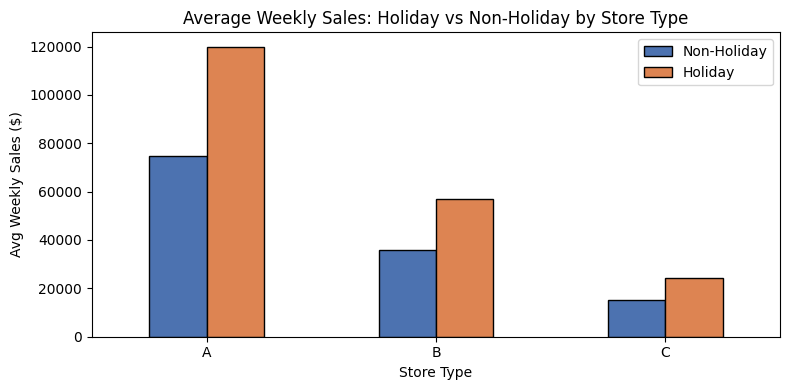

In [19]:
q2 = f"""
SELECT st.store_type, s.is_holiday,
    COUNT(*)                                 AS num_weeks,
    ROUND(AVG(s.weekly_sales)::numeric, 2)   AS avg_weekly_sales,
    ROUND(SUM(s.weekly_sales)::numeric, 2)   AS total_sales
FROM {SCHEMA}.sales s
JOIN {SCHEMA}.store st ON s.store_id = st.store_id
GROUP BY st.store_type, s.is_holiday
ORDER BY st.store_type, s.is_holiday DESC;
"""
df_q2 = pd.read_sql_query(q2, engine)
print('Query 2 — Holiday vs Non-Holiday Sales')
print(df_q2)

# Plot
pivot = df_q2.pivot(index='store_type', columns='is_holiday', values='avg_weekly_sales')
pivot.columns = ['Non-Holiday', 'Holiday']
pivot.plot(kind='bar', figsize=(8,4), color=['#4C72B0','#DD8452'], edgecolor='black')
plt.title('Average Weekly Sales: Holiday vs Non-Holiday by Store Type')
plt.ylabel('Avg Weekly Sales ($)')
plt.xlabel('Store Type')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../dashboard/holiday_vs_regular.png', dpi=150)
plt.show()


In [21]:
q3 = f"""
SELECT s.store_id, st.store_type,
    ROUND(AVG(s.weekly_sales)::numeric, 2)  AS avg_weekly_sales,
    ROUND(SUM(
        COALESCE(f.markdown_1,0)+COALESCE(f.markdown_2,0)
        +COALESCE(f.markdown_3,0)+COALESCE(f.markdown_4,0)+COALESCE(f.markdown_5,0)
    )::numeric, 2) AS total_markdown_spend,
    ROUND(
        (AVG(s.weekly_sales)::numeric) /
        NULLIF(AVG(
            COALESCE(f.markdown_1,0)+COALESCE(f.markdown_2,0)
            +COALESCE(f.markdown_3,0)+COALESCE(f.markdown_4,0)+COALESCE(f.markdown_5,0)
        )::numeric, 0)
    , 2) AS sales_per_markdown_dollar
FROM  {SCHEMA}.sales s
JOIN  {SCHEMA}.store st ON s.store_id = st.store_id
LEFT JOIN {SCHEMA}.features f ON s.store_id=f.store_id AND s.sale_date=f.feature_date
GROUP BY s.store_id, st.store_type
ORDER BY avg_weekly_sales DESC
LIMIT 20;
"""
df_q3 = pd.read_sql_query(q3, engine)
print('Query 3 — Markdown Effectiveness (top 20 stores)')
print(df_q3.head(10))


Query 3 — Markdown Effectiveness (top 20 stores)
   store_id store_type  avg_weekly_sales  total_markdown_spend  \
0        32          A          97186.87            13730878.6   
1        41          A          96734.57            14866704.4   
2         5          A          96174.32            14108826.8   
3         1          A          96123.40            13852874.2   
4        11          A          93703.21            15035943.8   
5        37          A          93389.21            14860848.0   
6         6          A          92986.52            14424859.4   
7        47          A          91591.88            14626336.8   
8        38          A          89983.78            14088292.4   
9        23          A          89627.90            14673320.6   

   sales_per_markdown_dollar  
0                      22.08  
1                      20.30  
2                      21.27  
3                      21.65  
4                      19.44  
5                      19.61  
6      

In [23]:
q4 = f"""
SELECT
    TO_CHAR(s.sale_date,'YYYY-MM') AS year_month,
    d.dept_name,
    ROUND(SUM(s.weekly_sales)::numeric, 2)   AS total_monthly_sales,
    ROUND(AVG(s.weekly_sales)::numeric, 2)   AS avg_weekly_sales
FROM {SCHEMA}.sales s
LEFT JOIN {SCHEMA}.department d ON s.dept_id = d.dept_id
GROUP BY year_month, d.dept_name
ORDER BY year_month DESC, total_monthly_sales DESC
LIMIT 100;
"""
df_q4 = pd.read_sql_query(q4, engine)
print('Query 4 — Monthly Demand Aggregation')
print(df_q4.head(12))


Query 4 — Monthly Demand Aggregation
   year_month      dept_name  total_monthly_sales  avg_weekly_sales
0        None  Department 20         3.639011e+08          77425.76
1        None  Department 19         3.505931e+08          74594.28
2        None  Department 18         3.420003e+08          72766.03
3        None  Department 17         3.283065e+08          69852.45
4        None  Department 16         3.230773e+08          68739.86
5        None  Department 15         3.131142e+08          66620.05
6        None  Department 14         3.004191e+08          63918.96
7        None  Department 13         2.899338e+08          61688.05
8        None  Department 12         2.868230e+08          61026.18
9        None  Department 11         2.784751e+08          59250.02
10       None  Department 10         2.643381e+08          56242.16
11       None   Department 9         2.556679e+08          54397.43


Query 5 — Store Type Performance
  store_type  num_stores  total_revenue  avg_weekly_sales  avg_store_size
0          A          26   6.495013e+09          80066.73        178797.0
1          B          16   1.914609e+09          38353.55        107238.0
2          C           8   4.049221e+08          16222.84         58350.0


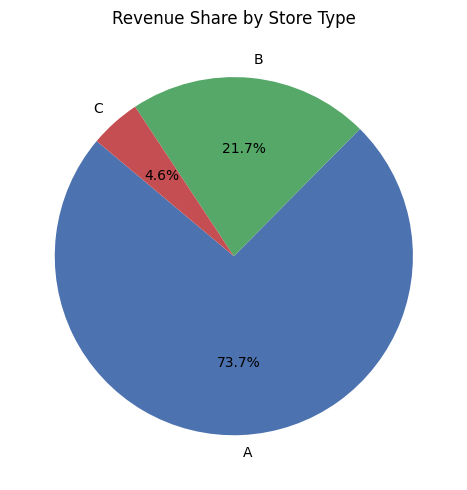

In [25]:
q5 = f"""
SELECT st.store_type,
    COUNT(DISTINCT st.store_id)  AS num_stores,
    ROUND(SUM(s.weekly_sales)::numeric, 2) AS total_revenue,
    ROUND(AVG(s.weekly_sales)::numeric, 2) AS avg_weekly_sales,
    ROUND(AVG(st.store_size)::numeric, 0)  AS avg_store_size
FROM {SCHEMA}.sales s
JOIN {SCHEMA}.store st ON s.store_id = st.store_id
GROUP BY st.store_type
ORDER BY total_revenue DESC;
"""
df_q5 = pd.read_sql_query(q5, engine)
print('Query 5 — Store Type Performance')
print(df_q5)

# Pie chart
fig, ax = plt.subplots(figsize=(6,5))
ax.pie(df_q5['total_revenue'], labels=df_q5['store_type'],
       autopct='%1.1f%%', startangle=140, colors=['#4C72B0','#55A868','#C44E52'])
ax.set_title('Revenue Share by Store Type')
plt.tight_layout()
plt.savefig('../dashboard/store_type_revenue.png', dpi=150)
plt.show()


In [26]:
# ── QUERY 6: Department Sales Outliers ──
q6 = f"""
WITH percentiles AS (
    SELECT PERCENTILE_CONT(0.25) WITHIN GROUP (ORDER BY weekly_sales) AS q1,
           PERCENTILE_CONT(0.75) WITHIN GROUP (ORDER BY weekly_sales) AS q3
    FROM {SCHEMA}.sales
),
bounds AS (
    SELECT q1, q3,
           q1 - 1.5*(q3-q1) AS lower_bound,
           q3 + 1.5*(q3-q1) AS upper_bound
    FROM percentiles
)
SELECT s.store_id, d.dept_name, s.sale_date, s.weekly_sales,
       b.lower_bound, b.upper_bound,
       CASE WHEN s.weekly_sales > b.upper_bound THEN 'High Outlier'
            WHEN s.weekly_sales < b.lower_bound THEN 'Low Outlier' END AS outlier_type
FROM {SCHEMA}.sales s
CROSS JOIN bounds b
LEFT JOIN {SCHEMA}.department d ON s.dept_id = d.dept_id
WHERE s.weekly_sales < b.lower_bound OR s.weekly_sales > b.upper_bound
ORDER BY s.weekly_sales DESC
LIMIT 50;
"""
df_q6 = pd.read_sql_query(q6, engine)
print('Query 6 — Sales Outliers')
print(df_q6['outlier_type'].value_counts())
df_q6.head(10)

Query 6 — Sales Outliers
outlier_type
High Outlier    50
Name: count, dtype: int64


,store_id,dept_name,sale_date,weekly_sales,lower_bound,upper_bound,outlier_type
0,41,Department 20,None,505958.73,-66266.255,167126.325,High Outlier
1,6,Department 20,None,489823.07,-66266.255,167126.325,High Outlier
2,5,Department 17,None,485963.00,-66266.255,167126.325,High Outlier
3,41,Department 20,None,483333.16,-66266.255,167126.325,High Outlier
4,24,Department 20,None,479940.11,-66266.255,167126.325,High Outlier
5,37,Department 20,None,475421.47,-66266.255,167126.325,High Outlier
6,11,Department 18,None,474171.29,-66266.255,167126.325,High Outlier
7,1,Department 19,None,461451.81,-66266.255,167126.325,High Outlier
8,38,Department 19,None,460913.71,-66266.255,167126.325,High Outlier
9,37,Department 19,None,456586.78,-66266.255,167126.325,High Outlier


In [28]:
# ── QUERY 7: CPI & Unemployment Impact ──
q7 = f"""
SELECT
    CASE WHEN f.cpi < 130 THEN 'Low CPI'
         WHEN f.cpi < 160 THEN 'Mid CPI' ELSE 'High CPI' END AS cpi_bucket,
    CASE WHEN f.unemployment < 6 THEN 'Low Unemp'
         WHEN f.unemployment < 9 THEN 'Mid Unemp' ELSE 'High Unemp' END AS unemp_bucket,
    COUNT(*) AS num_records,
    ROUND(AVG(s.weekly_sales)::numeric, 2) AS avg_weekly_sales
FROM {SCHEMA}.sales s
JOIN {SCHEMA}.features f ON s.store_id=f.store_id AND s.sale_date=f.feature_date
WHERE f.cpi IS NOT NULL AND f.unemployment IS NOT NULL
GROUP BY cpi_bucket, unemp_bucket
ORDER BY avg_weekly_sales DESC;
"""
df_q7 = pd.read_sql_query(q7, engine)
print('Query 7 — CPI & Unemployment Impact on Sales')
print(df_q7)


Query 7 — CPI & Unemployment Impact on Sales
  cpi_bucket unemp_bucket  num_records  avg_weekly_sales
0   High CPI   High Unemp         8880          55770.49
1   High CPI    Low Unemp        26200          55684.84
2   High CPI    Mid Unemp        26920          54839.44


In [30]:
# ── QUERY 8: Fuel Price Sensitivity ──
q8 = f"""
SELECT
    CASE WHEN f.fuel_price < 3.0 THEN 'Cheap (<$3)'
         WHEN f.fuel_price < 3.5 THEN 'Normal ($3-3.5)'
         WHEN f.fuel_price < 4.0 THEN 'High ($3.5-4)'
         ELSE 'Very High (>$4)' END AS fuel_bucket,
    COUNT(*) AS num_records,
    ROUND(AVG(s.weekly_sales)::numeric, 2) AS avg_weekly_sales
FROM {SCHEMA}.sales s
JOIN {SCHEMA}.features f ON s.store_id=f.store_id AND s.sale_date=f.feature_date
WHERE f.fuel_price IS NOT NULL
GROUP BY fuel_bucket
ORDER BY avg_weekly_sales DESC;
"""
df_q8 = pd.read_sql_query(q8, engine)
print('Query 8 — Fuel Price vs Weekly Sales')
print(df_q8)


Query 8 — Fuel Price vs Weekly Sales
       fuel_bucket  num_records  avg_weekly_sales
0    High ($3.5-4)        10220          56354.61
1      Cheap (<$3)        10420          55460.35
2  Very High (>$4)        30500          55449.50
3  Normal ($3-3.5)        10860          53905.32


Query 9 — Top 20 Departments by Revenue
   dept_id      dept_name  total_revenue  avg_weekly_sales  revenue_rank
0       20  Department 20   5.923036e+08          75936.35             1
1       19  Department 19   5.725349e+08          73401.92             2
2       18  Department 18   5.601886e+08          71819.05             3
3       17  Department 17   5.398004e+08          69205.18             4
4       16  Department 16   5.296860e+08          67908.46             5
5       15  Department 15   5.089252e+08          65246.82             6
6       14  Department 14   4.917602e+08          63046.18             7
7       13  Department 13   4.749228e+08          60887.53             8
8       12  Department 12   4.671906e+08          59896.23             9
9       11  Department 11   4.541135e+08          58219.69            10


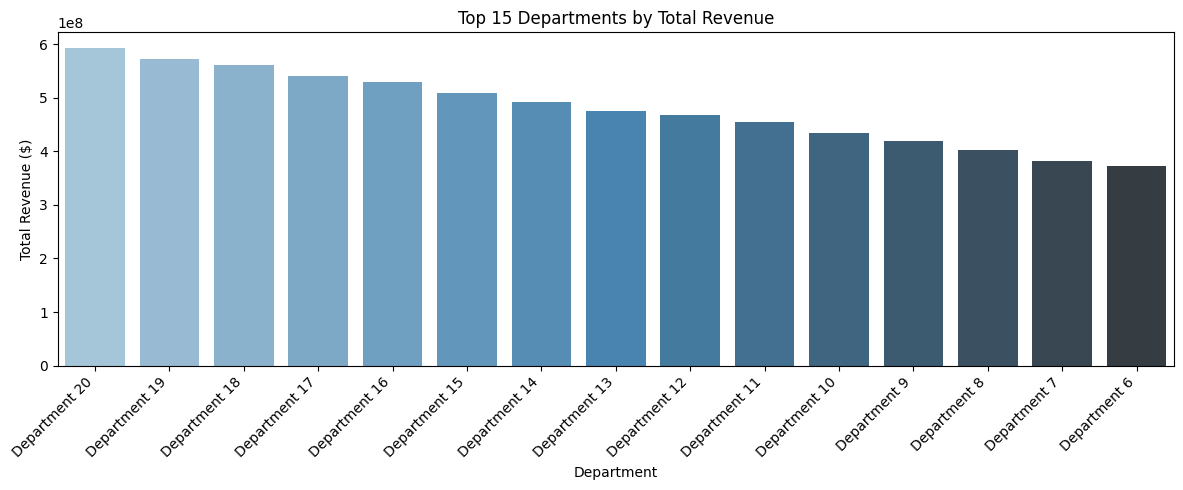

In [32]:
# ── QUERY 9: Top Departments by Revenue ──
q9 = f"""
SELECT d.dept_id, COALESCE(d.dept_name,'Dept '||d.dept_id) AS dept_name,
    ROUND(SUM(s.weekly_sales)::numeric, 2) AS total_revenue,
    ROUND(AVG(s.weekly_sales)::numeric, 2) AS avg_weekly_sales,
    RANK() OVER (ORDER BY SUM(s.weekly_sales) DESC) AS revenue_rank
FROM {SCHEMA}.sales s
LEFT JOIN {SCHEMA}.department d ON s.dept_id = d.dept_id
GROUP BY d.dept_id, d.dept_name
ORDER BY total_revenue DESC
LIMIT 20;
"""
df_q9 = pd.read_sql_query(q9, engine)
print('Query 9 — Top 20 Departments by Revenue')
print(df_q9.head(10))

# Bar chart
plt.figure(figsize=(12,5))
sns.barplot(data=df_q9.head(15), x='dept_name', y='total_revenue',
            palette='Blues_d')
plt.xticks(rotation=45, ha='right')
plt.title('Top 15 Departments by Total Revenue')
plt.ylabel('Total Revenue ($)')
plt.xlabel('Department')
plt.tight_layout()
plt.savefig('../dashboard/top_departments.png', dpi=150)
plt.show()


In [34]:
# ── QUERY 10: Data Quality Check ──
q10 = f"""
WITH dq AS (
    SELECT 'Sales with no Store'          AS issue, COUNT(*) AS cnt
    FROM {SCHEMA}.sales s LEFT JOIN {SCHEMA}.store st ON s.store_id=st.store_id
    WHERE st.store_id IS NULL
    UNION ALL
    SELECT 'Negative weekly_sales',        COUNT(*) FROM {SCHEMA}.sales WHERE weekly_sales < 0
    UNION ALL
    SELECT 'NULL weekly_sales',            COUNT(*) FROM {SCHEMA}.sales WHERE weekly_sales IS NULL
    UNION ALL
    SELECT 'Features with NULL CPI',       COUNT(*) FROM {SCHEMA}.features WHERE cpi IS NULL
    UNION ALL
    SELECT 'Features with NULL fuel',      COUNT(*) FROM {SCHEMA}.features WHERE fuel_price IS NULL
    UNION ALL
    SELECT 'Sales rows without Features',  COUNT(*)
    FROM {SCHEMA}.sales s
    LEFT JOIN {SCHEMA}.features f ON s.store_id=f.store_id AND s.sale_date=f.feature_date
    WHERE f.store_id IS NULL
)
SELECT * FROM dq ORDER BY cnt DESC;
"""
df_q10 = pd.read_sql_query(q10, engine)
print('Query 10 — Data Quality Summary')
print(df_q10)


Query 10 — Data Quality Summary
                         issue    cnt
0  Sales rows without Features  94000
1      Features with NULL fuel      0
2       Features with NULL CPI      0
3            NULL weekly_sales      0
4        Negative weekly_sales      0
5          Sales with no Store      0


# STEP 9: Views in Action

In [35]:
# ── VIEW 1: Holiday Sales Uplift ──
vq1 = "SELECT * FROM retail.vw_holiday_sales_uplift;"
df_v1 = pd.read_sql_query(vq1, engine)
print('View 1 — Holiday Uplift by Store Type')
display(df_v1)

# ── VIEW 2: Markdown Effectiveness ──
vq2 = "SELECT * FROM retail.vw_markdown_effectiveness WHERE total_markdown_spend > 0 ORDER BY markdown_roi DESC LIMIT 10;"
df_v2 = pd.read_sql_query(vq2, engine)
print('View 2 — Top 10 Stores by Markdown ROI')
display(df_v2)

# ── VIEW 3: Top Departments ──
vq3 = "SELECT * FROM retail.vw_top_departments_by_revenue LIMIT 10;"
df_v3 = pd.read_sql_query(vq3, engine)
print('View 3 — Top 10 Departments by Revenue')
display(df_v3)

View 1 — Holiday Uplift by Store Type


,store_type,avg_holiday_sales,avg_regular_sales,uplift_pct
0,A,119877.74,74873.98,60.11
1,B,57148.15,35902.09,59.18
2,C,24187.44,15183.98,59.30


View 2 — Top 10 Stores by Markdown ROI


,store_id,store_type,region,weeks_tracked,avg_weekly_sales,total_markdown_spend,avg_weekly_markdown,markdown_roi
0,32,A,East,62,97186.87,13730878.6,4400.92,22.08
1,1,A,North,62,96123.40,13852874.2,4440.02,21.65
2,5,A,North,62,96174.32,14108826.8,4522.06,21.27
3,41,A,South,62,96734.57,14866704.4,4764.97,20.30
4,6,A,West,62,92986.52,14424859.4,4623.35,20.11
5,38,A,South,62,89983.78,14088292.4,4515.48,19.93
6,37,A,South,62,93389.21,14860848.0,4763.09,19.61
7,47,A,East,62,91591.88,14626336.8,4687.93,19.54
8,11,A,West,62,93703.21,15035943.8,4819.21,19.44
9,23,A,North,62,89627.90,14673320.6,4702.99,19.06


View 3 — Top 10 Departments by Revenue


,dept_id,dept_name,stores_carrying,total_weekly_records,total_revenue,avg_weekly_sales,peak_weekly_sales,revenue_rank
0,20,Department 20,50,7800,5.923036e+08,75936.35,505958.73,1
1,19,Department 19,50,7800,5.725349e+08,73401.92,461451.81,2
2,18,Department 18,50,7800,5.601886e+08,71819.05,474171.29,3
3,17,Department 17,50,7800,5.398004e+08,69205.18,485963.00,4
4,16,Department 16,50,7800,5.296860e+08,67908.46,412331.29,5
5,15,Department 15,50,7800,5.089252e+08,65246.82,456288.21,6
6,14,Department 14,50,7800,4.917602e+08,63046.18,425740.12,7
7,13,Department 13,50,7800,4.749228e+08,60887.53,394935.35,8
8,12,Department 12,50,7800,4.671906e+08,59896.23,391438.77,9
9,11,Department 11,50,7800,4.541135e+08,58219.69,375980.07,10


# STEP 10: Demand Forecasting (SARIMA + Prophet)
Uses `vw_store_weekly_summary` to get a clean time-series for Store 1.

Time series length: 153 weeks
                     y
ds                    
2024-11-08  1630636.64
2024-11-15  1630636.64
2024-11-22  1630636.64
2024-11-29  1630636.64
2024-12-06  1630636.64


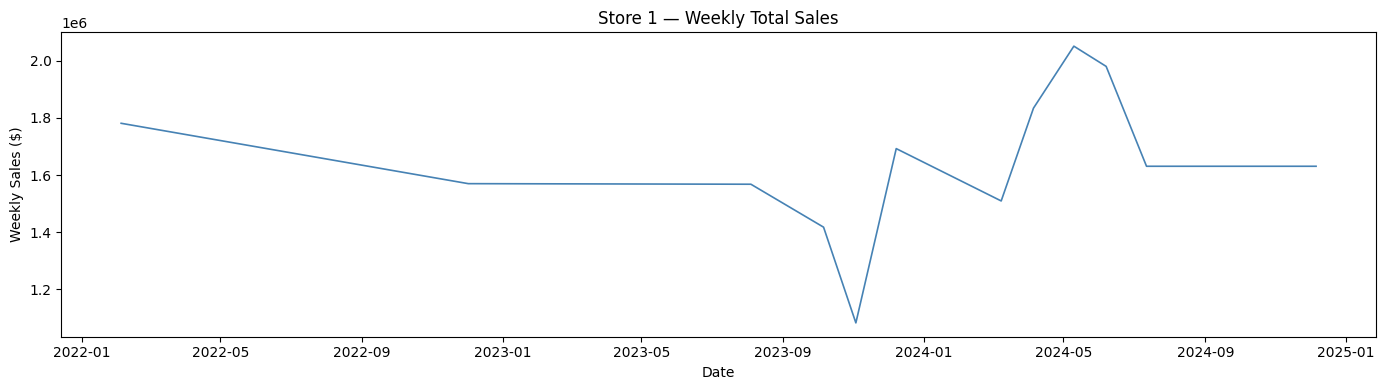

In [36]:
# Load time series for Store 1
ts_query = """
SELECT sale_date AS ds, total_weekly_sales AS y
FROM retail.vw_store_weekly_summary
WHERE store_id = 1
ORDER BY sale_date;
"""
df_ts = pd.read_sql_query(ts_query, engine)
df_ts['ds'] = pd.to_datetime(df_ts['ds'])
df_ts = df_ts.set_index('ds').asfreq('W-FRI')  # weekly frequency
df_ts['y'] = df_ts['y'].interpolate()          # fill any gaps

print(f'Time series length: {len(df_ts)} weeks')
print(df_ts.tail())

# Plot raw series
plt.figure(figsize=(14,4))
plt.plot(df_ts.index, df_ts['y'], linewidth=1.2, color='steelblue')
plt.title('Store 1 — Weekly Total Sales')
plt.ylabel('Weekly Sales ($)')
plt.xlabel('Date')
plt.tight_layout()
plt.savefig('../dashboard/store1_timeseries.png', dpi=150)
plt.show()

Fitting SARIMA(1,1,1)(1,1,1,52)...
                                     SARIMAX Results                                      
Dep. Variable:                                  y   No. Observations:                  153
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 52)   Log Likelihood                -532.506
Date:                            Tue, 19 May 2026   AIC                           1075.011
Time:                                    13:15:51   BIC                           1084.155
Sample:                                01-07-2022   HQIC                          1078.436
                                     - 12-06-2024                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7959      0.373      2.135      0.033       0.065       1.527


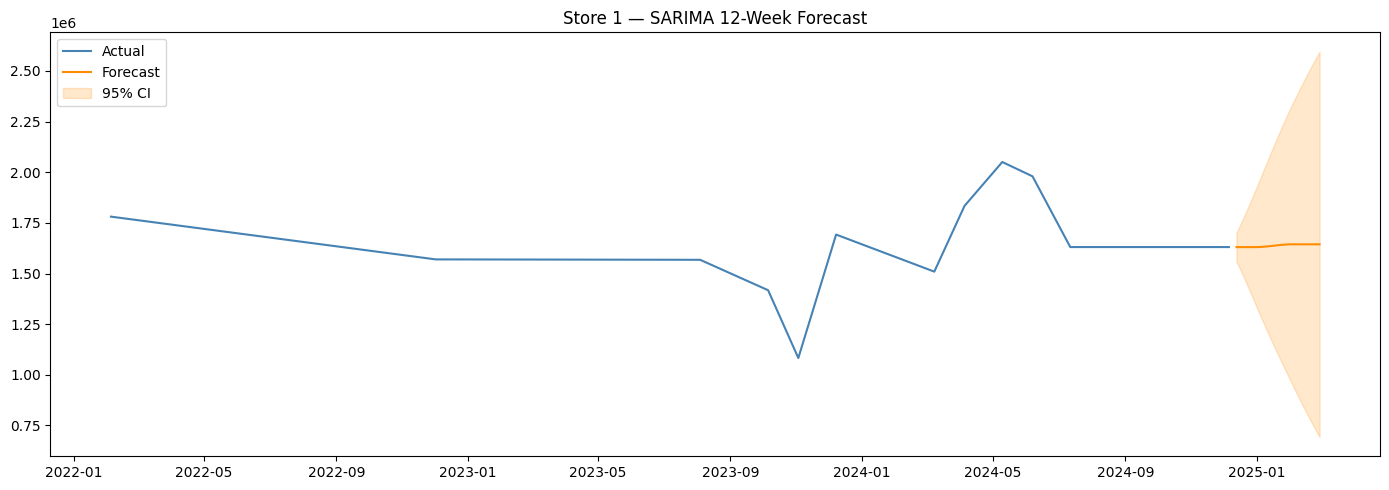

In [37]:
if SARIMA_AVAILABLE and len(df_ts) >= 52:
    print('Fitting SARIMA(1,1,1)(1,1,1,52)...')
    model = SARIMAX(df_ts['y'],
                    order=(1,1,1),
                    seasonal_order=(1,1,1,52),
                    enforce_stationarity=False,
                    enforce_invertibility=False)
    result = model.fit(disp=False)
    print(result.summary())

    # Forecast next 12 weeks
    forecast = result.get_forecast(steps=12)
    fc_mean  = forecast.predicted_mean
    fc_ci    = forecast.conf_int()

    plt.figure(figsize=(14,5))
    plt.plot(df_ts.index, df_ts['y'], label='Actual', color='steelblue')
    plt.plot(fc_mean.index, fc_mean, label='Forecast', color='darkorange')
    plt.fill_between(fc_ci.index, fc_ci.iloc[:,0], fc_ci.iloc[:,1],
                     alpha=0.2, color='darkorange', label='95% CI')
    plt.title('Store 1 — SARIMA 12-Week Forecast')
    plt.legend()
    plt.tight_layout()
    plt.savefig('../dashboard/sarima_forecast.png', dpi=150)
    plt.show()
else:
    print('Skipping SARIMA (library not available or insufficient data).')

13:16:03 - cmdstanpy - INFO - Chain [1] start processing
13:16:03 - cmdstanpy - INFO - Chain [1] done processing


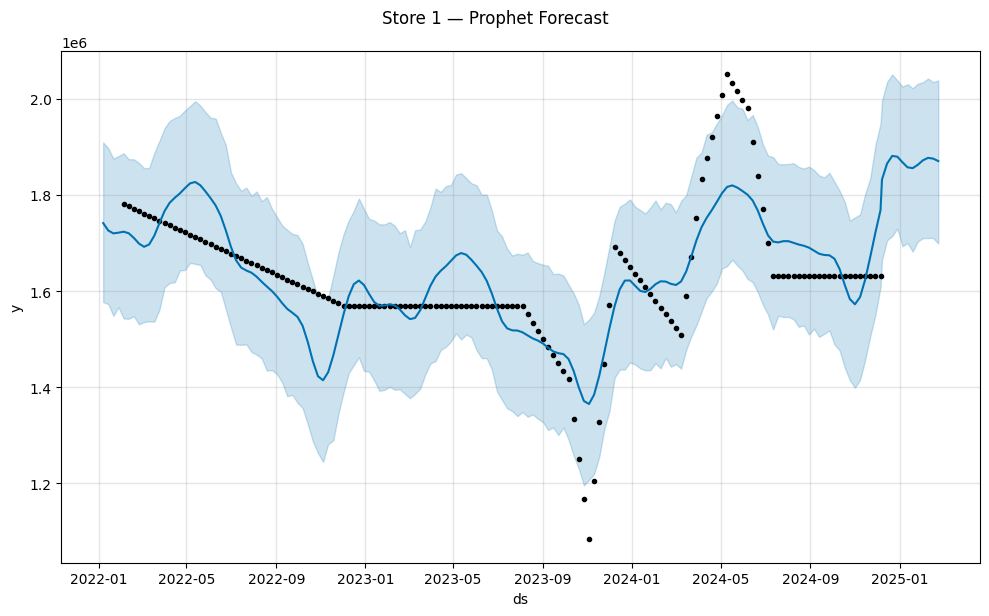

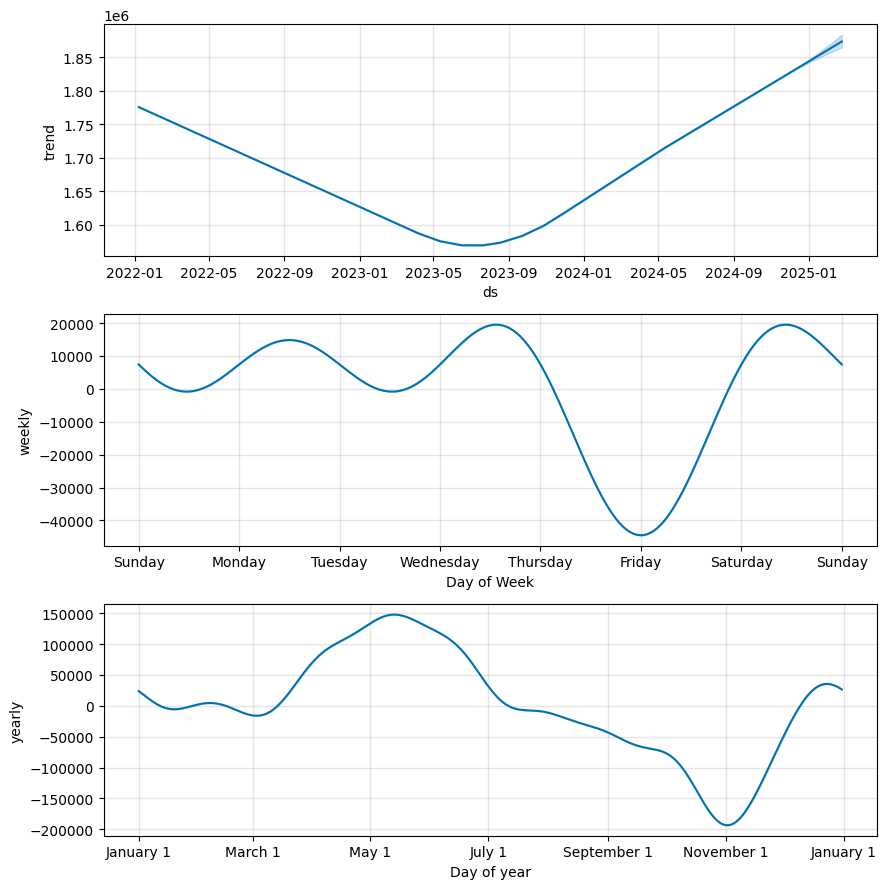

In [38]:
if PROPHET_AVAILABLE and len(df_ts) >= 20:
    prophet_df = df_ts.reset_index().rename(columns={'ds':'ds','y':'y'})
    prophet_df['ds'] = pd.to_datetime(prophet_df['ds'])

    m = Prophet(yearly_seasonality=True, weekly_seasonality=True,
                daily_seasonality=False, interval_width=0.95)
    m.fit(prophet_df)

    future   = m.make_future_dataframe(periods=12, freq='W')
    forecast  = m.predict(future)

    fig1 = m.plot(forecast)
    fig1.suptitle('Store 1 — Prophet Forecast', y=1.02)
    fig1.savefig('../dashboard/prophet_forecast.png', dpi=150, bbox_inches='tight')
    plt.show()

    fig2 = m.plot_components(forecast)
    fig2.savefig('../dashboard/prophet_components.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Skipping Prophet (library not available or insufficient data).')

## Summary
All 10 analytical queries, 4 views, trigger demos, stored procedures, and demand forecasting are complete.
Charts are saved to `dashboard/` for use in the Streamlit app.